# BioSample curation pipeline: data and trace-back results

This notebook explains what the BioSample curation pipeline produced, how extracted values were checked against their source records, and what the results show. It covers the full collection of curated BioSamples, the matching methods used to trace values back to source text, the unresolved cases, and the main limitations of the curation output.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_trace_back_pipeline.ipynb")

### Table of contents


[BioSample curation pipeline: data and trace-back results](#BioSample-curation-pipeline:-data-and-trace-back-results)
- [Setup](#Setup)
- [Pipeline and dataset](#Pipeline-and-dataset)
  - [Main trace-back results](#Main-trace-back-results)
  - [Examples of each matching method](#Examples-of-each-matching-method)
  - [Unresolved values](#Unresolved-values)
  - [Types of errors](#Types-of-errors)
  - [How reliable is this independent read?](#How-reliable-is-this-independent-read?)
  - [LLM evidence review](#LLM-evidence-review)
  - [Matching methodology](#Matching-methodology)
- [Appendix: pipeline limitations](#Appendix:-pipeline-limitations)
  - [Ontology mapper accepts a coincidental short-symbol match instead of returning no match](#Ontology-mapper-accepts-a-coincidental-short-symbol-match-instead-of-returning-no-match)
  - [Correct extraction, wrong nearby term](#Correct-extraction,-wrong-nearby-term)
  - [Negation swallowed into a confidently-named, wrong compound](#Negation-swallowed-into-a-confidently-named,-wrong-compound)
  - [General fabrication rate, projected onto the full crate](#General-fabrication-rate,-projected-onto-the-full-crate)

## Setup

In [2]:
# IMPORTS
import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from bs_entries import (
    MATCH_STRATEGIES,
    bs_record_table,
    find_bs_entry_in_files,
    get_accession,
    iter_bs_entries,
    matches_display_table,
    scan_accessions,
    verify_extracted_against_raw,
    verify_extracted_against_raw_rows,
)
from notebook_utils import display_with_nested_tables, md, table_covers_json
from ontology import build_field_ontology_indexes
from paths import (
    CRATE_CONFIG_DIR,
    CRATE_INPUTS_DIR,
    CRATE_ONTOLOGY_DIR,
    CRATE_RESULTS_DIR,
    INDEPENDENT_REVIEW_MODEL_COMPARISON_100_PARQUET,
    QWEN_INDEPENDENT_REVIEW_100_PARQUET,
    RUN_INDEX_TSV,
    TRACE_BACK_FULL_PARQUET,
)
from select_results import curated_entry_table, find_entry, load_select_result

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# THE FOUR CATEGORIES, AS A FILTER OVER run_index.tsv's `dataset` COLUMN
@dataclass(frozen=True)
class Category:
    name: str
    organism: str
    technology: str
    dataset_prefix: str  # matches run_index.tsv's `dataset` column by startswith


CATEGORIES = [
    Category("DDBJ RNA-Seq", "Homo sapiens", "RNA-Seq", "rnaseq_human"),
    Category("DDBJ RNA-Seq", "Mus musculus", "RNA-Seq", "rnaseq_mouse"),
    Category("ChIP-Atlas", "Homo sapiens", "ChIP-Atlas (hg38)", "chipatlas_hg38"),
    Category("ChIP-Atlas", "Mus musculus", "ChIP-Atlas (mm10)", "chipatlas_mm10"),
]

run_index = pd.read_csv(RUN_INDEX_TSV, sep="\t")


def category_input_files(category: Category) -> list[Path]:
    datasets = sorted(run_index.loc[run_index["dataset"].str.startswith(category.dataset_prefix), "dataset"].unique())
    files: list[Path] = []
    for dataset in datasets:
        files.extend(sorted((CRATE_INPUTS_DIR / dataset).glob("bs_entries_*.jsonl")))
    return files

In [4]:
# ONTOLOGY INDEXES, BUILT ONCE PER SELECT CONFIG AND REUSED EVERYWHERE THEY'RE NEEDED
_ontology_indexes_cache: dict[str, dict] = {}


def get_ontology_indexes(select_config_filename: str) -> dict:
    if select_config_filename not in _ontology_indexes_cache:
        with (CRATE_CONFIG_DIR / select_config_filename).open() as f:
            select_config = json.load(f)
        fields = list(select_config.get("fields", {}).keys())
        _ontology_indexes_cache[select_config_filename] = build_field_ontology_indexes(select_config, CRATE_ONTOLOGY_DIR, fields)
    return _ontology_indexes_cache[select_config_filename]

## Pipeline and dataset

The pipeline takes BioSample records and produces curated field values such as disease, tissue, cell type, gene, and treatment. Each extracted value is checked against the same source record. A value is counted as traced when the record contains direct or curated supporting text; values without a match remain in the unresolved group for further review.

In [5]:
# DATASET INVENTORY AND TRACE-BACK COVERAGE
trace_back_full = pd.read_parquet(TRACE_BACK_FULL_PARQUET)

n_extracted_values = len(trace_back_full)
n_biosamples = trace_back_full["accession"].nunique()
strategy_counts = trace_back_full["strategy"].value_counts().reindex(MATCH_STRATEGIES + ["not found"], fill_value=0)
n_traced = int(strategy_counts.drop("not found").sum())
n_not_found = int(strategy_counts["not found"])

md(
    f"The dataset contains **{n_extracted_values:,} extracted field values** from **{n_biosamples:,} BioSamples**. "
    f"The deterministic trace-back matched **{n_traced:,} values ({100 * n_traced / n_extracted_values:.1f}%)**. "
    f"The remaining **{n_not_found:,} values ({100 * n_not_found / n_extracted_values:.1f}%)** have no deterministic textual match and form the residual for targeted review, including the LLM evidence checks shown later."
)

The dataset contains **8,194,813 extracted field values** from **3,989,387 BioSamples**. The deterministic trace-back matched **7,890,974 values (96.3%)**. The remaining **303,839 values (3.7%)** have no deterministic textual match and form the residual for targeted review, including the LLM evidence checks shown later.

### Main trace-back results

The matching cascade tests each extracted value against the source record, moving from exact text to increasingly tolerant methods. The table and plot below show how often each method succeeds for every field.

In [6]:
# COUNTS PER (FIELD, STRATEGY), EXCLUDING FIELDS WITH NO EXTRACTED VALUE
STRATEGY_ORDER = [*MATCH_STRATEGIES, "not found"]


def strategy_breakdown(trace_back: pd.DataFrame) -> pd.DataFrame:
    counts = trace_back.groupby(["target_field", "strategy"]).size().unstack(fill_value=0)
    counts.columns.name = None  # unstack() leaves "strategy" as the column axis's name, which pandas prints as a spurious extra header row
    for strategy in STRATEGY_ORDER:
        if strategy not in counts.columns:
            counts[strategy] = 0
    counts = counts[STRATEGY_ORDER]
    counts["n_with_value"] = counts.sum(axis=1)
    counts["pct_found"] = (100 * (counts["n_with_value"] - counts["not found"]) / counts["n_with_value"]).round(1)
    return counts.reset_index().sort_values("pct_found").reset_index(drop=True)

In [7]:
# % DETERMINISTICALLY TRACED, PER FIELD
strategy_stats_full = strategy_breakdown(trace_back_full)
strategy_stats_full.style.format({**{col: "{:,}" for col in [*STRATEGY_ORDER, "n_with_value"]}, "pct_found": "{:.1f}"})

,target_field,exact,case-insensitive,normalized,ontology synonym,bag of words,fuzzy,not found,n_with_value,pct_found
0,knockdown_gene,"53,761","1,642","20,143",642,2,26,"9,320","85,536",89.1
1,knockout_gene,"327,959","8,511","55,451","11,333",0,174,"41,035","444,463",90.8
2,overexpressed_gene,"164,884","4,876","20,262","1,696",56,48,"14,730","206,552",92.9
3,disease,"533,108","46,927","2,396","19,823",105,"1,049","31,624","635,032",95.0
4,cell_type,"1,481,228","35,046","270,909","14,053",460,"4,330","84,469","1,890,495",95.5
5,tissue,"2,460,412","199,081","19,402","18,166",44,"4,780","93,114","2,794,999",96.7
6,drug,"745,717","14,430","3,430","7,517",209,525,"19,800","791,628",97.5
7,chip_antigen,"347,358","4,166","1,396","1,184",3,139,"6,496","360,742",98.2
8,cell_line,"964,387","6,148","9,302","1,695",22,561,"3,251","985,366",99.7


In [8]:
# % TRACED BACK PER STRATEGY, ACROSS ALL FIELDS COMBINED
total_checked = len(trace_back_full)
strategy_totals = trace_back_full["strategy"].value_counts().reindex(STRATEGY_ORDER, fill_value=0)

md(
    f"Across all **{total_checked:,}** extracted field values checked: "
    + ", ".join(f"**{n:,} ({100 * n / total_checked:.1f}%)** by `{strategy}`" for strategy, n in strategy_totals.items())
    + "."
)

Across all **8,194,813** extracted field values checked: **7,078,814 (86.4%)** by `exact`, **320,827 (3.9%)** by `case-insensitive`, **402,691 (4.9%)** by `normalized`, **76,109 (0.9%)** by `ontology synonym`, **901 (0.0%)** by `bag of words`, **11,632 (0.1%)** by `fuzzy`, **303,839 (3.7%)** by `not found`.

In [9]:
# HOW OFTEN A VALUE MATCHES MORE THAN ONE ATTRIBUTE
found_full = trace_back_full[trace_back_full["strategy"] != "not found"]
multi_match_full = found_full[found_full["n_matches"] > 1]

md(
    f"Of the **{len(found_full):,} extracted values traced back successfully**, **{len(multi_match_full):,} ({100 * len(multi_match_full) / len(found_full):.1f}%)** matched more than one attribute. "
    f"The remaining multiple matches are genuine ambiguity between equally specific attributes, such as `cell_type` and `disease` both containing the word \"cancer\", or the same fact appearing in more than one identifier field."
)

Of the **7,890,974 extracted values traced back successfully**, **589,035 (7.5%)** matched more than one attribute. The remaining multiple matches are genuine ambiguity between equally specific attributes, such as `cell_type` and `disease` both containing the word "cancer", or the same fact appearing in more than one identifier field.

In [10]:
# STACKED PLOT: % OF EXTRACTIONS FOUND PER TIER, PER FIELD
def _select_label_positions(candidates: list[float], min_gap: float = 6.0) -> list[float]:
    """From candidate label positions (cumulative % boundaries on one bar), picks which to
    actually render as text: always the largest, then each next-largest only if it's at
    least `min_gap` percentage points from the last one kept -- otherwise two close
    boundaries produce overlapping, unreadable text (e.g. 58% and 59% back to back).
    """
    ordered = sorted(set(candidates), reverse=True)
    kept: list[float] = []
    for value in ordered:
        if not kept or (kept[-1] - value) >= min_gap:
            kept.append(value)
    return kept


def plot_strategy_breakdown(stats: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    order = STRATEGY_ORDER
    # ordinal blue ramp for the matched tiers (darkest = strongest match), light red for failure --
    # all >=8:1 black-text contrast, checked with the same formula the dataviz skill's validator uses
    colors = {
        "exact": "#6da7ec",
        "case-insensitive": "#89b8ef",
        "normalized": "#a8c9f4",
        "ontology synonym": "#c6daf8",
        "bag of words": "#d4e4fa",
        "fuzzy": "#e3eefc",
        "not found": "#eb9a9a",
    }

    fields = stats.sort_values("pct_found")["target_field"].tolist()
    pct = stats.set_index("target_field")
    pct = pct[order].div(pct["n_with_value"], axis=0) * 100
    pct = pct.loc[fields]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = list(range(len(fields)))
    left = pd.Series(0.0, index=pct.index)
    for strategy in order:
        ax.barh(y_pos, pct[strategy], left=left, label=strategy, color=colors[strategy])
        left += pct[strategy]

    for y, field in zip(y_pos, fields):
        # candidate label positions are cumulative boundaries over the MATCHED tiers only (never
        # "not found", whose own boundary is trivially ~100% and tells the reader nothing) -- this
        # makes the largest candidate always `pct_found`, the one number that matters most, and
        # guarantees it's always the one shown even when the last matched slice is thin
        cum = 0.0
        candidates = []
        for strategy in MATCH_STRATEGIES:
            cum += pct.loc[field, strategy]
            if pct.loc[field, strategy] > 0:
                candidates.append(cum)
        for value in _select_label_positions(candidates):
            ax.text(value - 1, y, f"{value:.0f}", va="center", ha="right", fontsize=9, color="black")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fields)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of non-null extractions")
    ax.set_title("How extracted values were traced back to the raw input, by field")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

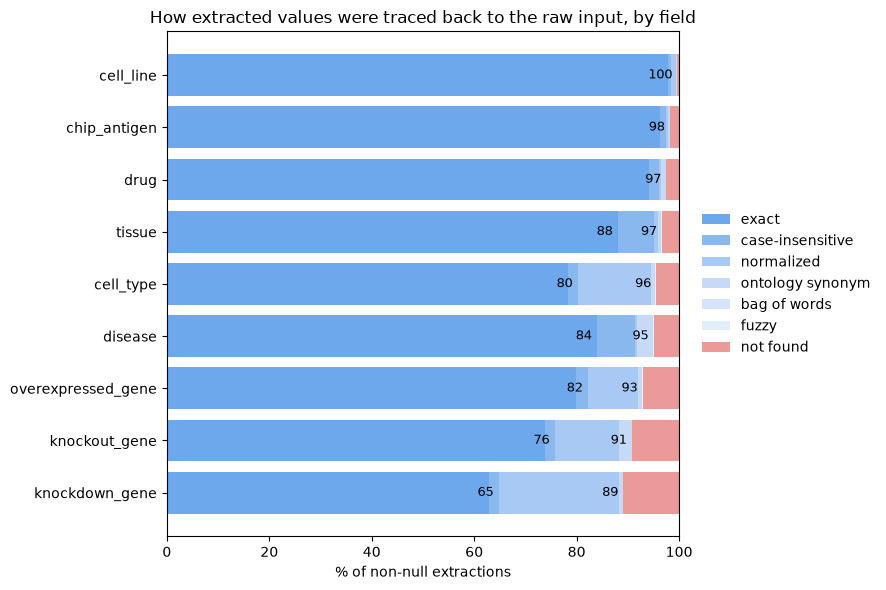

In [11]:
# STACKED PLOT OF strategy_stats_full
plot_strategy_breakdown(strategy_stats_full)

### Examples of each matching method

These examples show what the matching methods found in the source records. Bold text is the evidence used for the match; ontology information is included to show the concept assigned to the extracted value.

In [12]:
# ONE EXAMPLE PER STRATEGY: biosample_id | strategy | field | target_value | matches | assigned_term_id | assigned_term_label | assigned_term_synonyms
def one_example_per_strategy(trace_back: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for strategy in STRATEGY_ORDER:
        subset = trace_back[trace_back["strategy"] == strategy]
        if len(subset) == 0:
            continue
        row = subset.iloc[0]
        rows.append(
            {
                "biosample_id": row["accession"],
                "strategy": strategy,
                "field": row["target_field"],
                "target_value": row["target_value"],
                "matches": matches_display_table(row["raw_fields"], row["raw_texts"], row["raw_matched_phrase"]),
                "assigned_term_id": row["assigned_term_id"],
                "assigned_term_label": row["assigned_term_label"],
                "assigned_term_synonyms": row["assigned_term_synonyms"],
            }
        )
    # "llm" isn't a deterministic-cascade strategy, so it never appears in `trace_back` itself --
    # one curated example from the live Qwen3-8B production run instead, same row shape (see
    # "Precision and recall of the Qwen3-8B evidence tier" below for how that tier is evaluated).
    rows.append(
        {
            "biosample_id": "SAMN08141221",
            "strategy": "llm",
            "field": "disease",
            "target_value": "prostate cancer",
            "matches": matches_display_table(["source_name"], ["prostate tumor"], ["prostate tumor"]),
            "assigned_term_id": "MONDO:0008315",
            "assigned_term_label": "prostate cancer",
            "assigned_term_synonyms": "NGP - new growth of prostate; cancer of prostate gland; malignant neoplasm of prostate; malignant neoplasm of prostate gland; malignant neoplasm of the prostate; malignant prostate gland neoplasm; malignant prostate neoplasm; malignant prostate tumor; malignant prostate tumour; malignant tumor of prostate; malignant tumor of the prostate; malignant tumour of prostate; malignant tumour of the prostate; prostate gland cancer; prostatic cancer",
        }
    )
    return pd.DataFrame(rows, columns=["biosample_id", "strategy", "field", "target_value", "matches", "assigned_term_id", "assigned_term_label", "assigned_term_synonyms"])


display_with_nested_tables(one_example_per_strategy(trace_back_full))

### Unresolved values

A fresh 100-pattern sample was drawn from the deterministic cascade's current residual, restricted to accessions the live Qwen3-8B production run has already processed, and independently re-read against each record's own raw text -- by the same evidentiary standard the LLM evidence tier itself uses (a direct statement, or a specific, well-supported inference fully contained in the text; never outside domain knowledge). The table below shows, for every pattern, where the independent read found its evidence (if any) alongside what Qwen3-8B itself proposed, so the two can be compared directly. Rows are grouped first by whether the two agree, then by the kind of pattern involved.

In [13]:
# FRESH 100-SAMPLE: INDEPENDENT READ VS. QWEN3-8B, SIDE BY SIDE
unresolved_review = pd.read_parquet(QWEN_INDEPENDENT_REVIEW_100_PARQUET)


def review_display_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in df.iterrows():
        rows.append(
            {
                "accession": r["accession"],
                "target_field": r["target_field"],
                "target_value": r["target_value"],
                "agreement": r["agreement"],
                "failure_mode": r["failure_mode"],
                "claude_evidence": matches_display_table(r["claude_raw_fields"], r["claude_raw_texts"], r["claude_raw_matched_phrase"]),
                "qwen_evidence": matches_display_table(r["qwen_raw_fields"], r["qwen_raw_texts"], r["qwen_raw_matched_phrase"]),
            }
        )
    return pd.DataFrame(rows)


display_with_nested_tables(review_display_table(unresolved_review))

### Types of errors

Every unresolved row above is also categorized by the kind of gap it represents -- how the record's actual text differs from the target value, or why no evidence exists at all.

In [14]:
# TYPES OF ERRORS ACROSS THE SAMPLE
unresolved_review["failure_mode"].value_counts().rename_axis("failure_mode").reset_index(name="n")

,failure_mode,n
0,fused token (value's letters directly attached...,43
1,abbreviation (raw text abbreviates the value),21
2,requires domain knowledge beyond the record,13
3,"misspelling (typo, below fuzzy's safe length t...",8
4,"reworded (paraphrase, word-form, or punctuatio...",7
5,fabricated / no textual basis,6
6,compound token (word/phrase inserted between p...,1
7,value combines multiple separate attributes,1


### How reliable is this independent read?

The independent read above was done directly rather than delegated to a cheaper model, after checking why that matters: a smaller model (Claude Haiku) given the identical blind task over the same 100 patterns, and Qwen3-8B, are both scored below against the independent read as the reference.

In [15]:
# INDEPENDENT-READ RELIABILITY: A CHEAPER MODEL AND QWEN3-8B, BOTH SCORED AGAINST THE SAME READ
model_comparison = pd.read_parquet(INDEPENDENT_REVIEW_MODEL_COMPARISON_100_PARQUET)


def score_against_reference(verdicts: pd.Series, reference: pd.Series) -> dict[str, float]:
    model_found, ref_found = verdicts == "found", reference == "found"
    tp = int((model_found & ref_found).sum())
    fp = int((model_found & ~ref_found).sum())
    fn = int((~model_found & ref_found).sum())
    tn = int((~model_found & ~ref_found).sum())
    return {
        "found": int(model_found.sum()),
        "not_found": int((~model_found).sum()),
        "precision": tp / (tp + fp),
        "recall": tp / (tp + fn),
        "accuracy": (tp + tn) / len(verdicts),
    }


reliability = pd.DataFrame(
    {
        "Claude Haiku (blind)": score_against_reference(model_comparison["haiku_verdict"], model_comparison["sonnet_verdict"]),
        "Qwen3-8B": score_against_reference(model_comparison["qwen_verdict"], model_comparison["sonnet_verdict"]),
    }
).T
reliability.style.format({"found": "{:.0f}", "not_found": "{:.0f}", "precision": "{:.1%}", "recall": "{:.1%}", "accuracy": "{:.1%}"})

,found,not_found,precision,recall,accuracy
Claude Haiku (blind),59,41,94.9%,69.1%,72.0%
Qwen3-8B,61,39,96.7%,72.8%,76.0%


### LLM evidence review

An LLM (`Qwen3-8B`, served by vLLM) proposes evidence for values the deterministic cascade leaves unresolved. It is given the record's own raw text and asked for a direct statement or a specific, well-supported inference -- no outside world knowledge -- and every quote it proposes is independently checked against the source text before being trusted; a claim without a verified quote stays `not found`. This tier runs across the crate's full unresolved residual. Its precision and recall below come from the independent read above, over the same 100-pattern sample.

In [16]:
# QWEN3-8B EVIDENCE TIER: PRECISION AND RECALL AGAINST THE INDEPENDENT READ
agreement_counts = unresolved_review["agreement"].value_counts()
match = int(agreement_counts.get("match", 0))
mismatch = int(agreement_counts.get("mismatch", 0))
not_found_correct = int(agreement_counts.get("not found (correct)", 0))
not_found_incorrect = int(agreement_counts.get("not found (incorrect)", 0))
precision, recall = match / (match + mismatch), match / (match + not_found_incorrect)

md(
    f"Of the tier's **{match + mismatch} grounded `found` claims** in this sample, the independent read agreed with **{match} -- precision = {100 * precision:.1f}%**. "
    f"Of the **{match + not_found_incorrect} cases with genuine evidence**, the tier caught **{match} -- recall = {100 * recall:.1f}%**. "
    f"The remaining **{not_found_correct}** both agree have no textual basis."
)

Of the tier's **61 grounded `found` claims** in this sample, the independent read agreed with **59 -- precision = 96.7%**. Of the **81 cases with genuine evidence**, the tier caught **59 -- recall = 72.8%**. The remaining **17** both agree have no textual basis.

The tier is highly precise when it does propose evidence -- its rare disagreements with the independent read mostly turn out to require outside biomedical knowledge the tier correctly declines to assume. Its main gap is recall: of the values the independent read did confirm, a meaningful share are values fused directly onto a construct or identifier prefix/suffix with no separator, or short abbreviations, that the tier's current prompt tends to miss.

### Matching methodology

The deterministic cascade tries each extracted value against the source record through a fixed set of tiers, from strictest to most permissive: exact and case-insensitive substring match; a normalized match that strips parentheticals and collapses separators; an ontology-synonym match against the assigned term's registered label or synonyms, itself checked with bag-of-words and fuzzy tolerance; and a fuzzy, spelling-tolerant word match reserved for words of 6+ characters. It also resolves fused gene/construct names, bracketed phrases, out-of-order words, and visually similar characters, and searches every text value in the record -- not just the main descriptive fields -- so evidence isn't missed just because it appears elsewhere. Negation detection carries a high false-alarm rate and should be treated as a candidate for review rather than a final verdict.

## Appendix: pipeline limitations

Trace-back measures whether an extracted value has supporting text in its source record. It does not determine whether the extracted value is biologically correct or whether the assigned ontology concept is the best concept. The examples below document errors that source-text matching cannot resolve.

### Ontology mapper accepts a coincidental short-symbol match instead of returning no match

In [17]:
# NITRIC OXIDE (CHEBI:16480): HOW MANY ASSIGNMENTS ARE A COINCIDENTAL "No" MATCH, NOT THE REAL COMPOUND
no_rows = trace_back_full[trace_back_full["assigned_term_id"] == "CHEBI:16480"]
legit_no_values = {"D-Ala-NO", "DETA/NO", "NO", "nitric oxide"}
no_collisions = no_rows[~no_rows["target_value"].isin(legit_no_values)]

md(
    f"Of **{len(no_rows)} rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **{len(no_collisions)} ({100 * len(no_collisions) / len(no_rows):.0f}%)** "
    "are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field "
    f"(e.g. `\"{no_collisions['target_value'].iloc[0]}\"`, `\"{no_collisions['target_value'].iloc[4]}\"`), which the ontology search then matched to ChEBI's own "
    "two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word \"No\". Every one of these rows is "
    f"`{'`/`'.join(sorted(no_collisions['strategy'].unique()))}` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing "
    "here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't "
    "belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all."
)

Of **34 rows** crate-wide assigned `CHEBI:16480` (nitric oxide), **7 (21%)** are not nitric oxide at all -- they're free-text dietary/clinical notes extracted whole into the `drug` field (e.g. `"No casein, sugar, soy, corn, dyes"`, `"Mother GBS positive. Antibiotics during labor. Exclusively breastfed until 4 months. Will eat a wide range of food."`), which the ontology search then matched to ChEBI's own two-letter symbol for nitric oxide, `NO`, purely because they happen to start with the word "No". Every one of these rows is `exact` in this checker -- the sentence genuinely, verbatim appears in the raw record, so nothing here is a trace-back failure. Two separate pipeline mistakes compound: the LLM extracted a whole free-text note into a single-value field it doesn't belong in, and the ontology search then accepted a coincidental short-string match instead of returning no match at all.

### Correct extraction, wrong nearby term

In [18]:
# "bFGF" EXTRACTED CORRECTLY BUT MAPPED TO A DIFFERENT COMPOUND NAMED NEARBY IN THE SAME TEXT
bfgf_wrong = trace_back_full[(trace_back_full["target_value"] == "bFGF") & (trace_back_full["assigned_term_id"] == "CHEBI:86289")]

md(
    f"**{len(bfgf_wrong)} rows** extract `\"bFGF\"` -- found `{'`/`'.join(sorted(bfgf_wrong['strategy'].unique()))}` in the raw record every time -- but are "
    f"mapped to `{bfgf_wrong['assigned_term_id'].iloc[0]}` (**{bfgf_wrong['assigned_term_label'].iloc[0]}**), a different compound named right next to it "
    "in the same free-text attribute (\"...Chiron (CHIR), bFGF, DMH1 and SB-431542...\"). The ontology-mapping stage appears to have picked up a "
    "neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same \"nearby but wrong term\" failure family as the "
    "nitric-oxide case above, but via co-occurrence rather than a short-string coincidence."
)

**8 rows** extract `"bFGF"` -- found `exact` in the raw record every time -- but are mapped to `CHEBI:86289` (**DMH1**), a different compound named right next to it in the same free-text attribute ("...Chiron (CHIR), bFGF, DMH1 and SB-431542..."). The ontology-mapping stage appears to have picked up a neighboring co-mentioned drug name instead of resolving the one it was actually asked to -- the same "nearby but wrong term" failure family as the nitric-oxide case above, but via co-occurrence rather than a short-string coincidence.

### Negation swallowed into a confidently-named, wrong compound

In [19]:
# "nodox" (= "no doxorubicin") FABRICATED INTO A CONFIDENT, WRONG DRUG NAME -- AND WHY IT CAN'T BE FOUND BY SEARCH ALONE
nodox_row = trace_back_full[(trace_back_full["accession"] == "SAMN17884731") & (trace_back_full["target_field"] == "drug")].iloc[0]
other_no_drugs = trace_back_full[
    (trace_back_full["target_field"] == "drug") & trace_back_full["target_value"].str.match(r"^[Nn]o[a-z]{5,}$", na=False) & (trace_back_full["target_value"] != nodox_row["target_value"])
]

md(
    f"`{nodox_row['accession']}`'s raw `treatment` attribute reads `\"nodox\"` -- shorthand for \"no doxorubicin,\" i.e. the sample was explicitly **not** "
    f"given the drug -- but the pipeline extracted `\"{nodox_row['target_value']}\"` as a drug name in its own right (correctly `{nodox_row['strategy']}` in "
    f"this checker -- that string never appears anywhere in the record), then mapped it to `{nodox_row['assigned_term_id']}` "
    f"(**{nodox_row['assigned_term_label']}**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now "
    "implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also "
    f"can't be caught by an automated string search: **{other_no_drugs['target_value'].nunique()} other** legitimate drug names in this crate's `drug` field "
    f"happen to start with \"no\" (e.g. {', '.join(sorted(other_no_drugs['target_value'].str.lower().unique())[:4])}, ...), so a \"starts with no\" heuristic "
    "would swamp the one real case in false positives -- this one was only caught by hand."
)

`SAMN17884731`'s raw `treatment` attribute reads `"nodox"` -- shorthand for "no doxorubicin," i.e. the sample was explicitly **not** given the drug -- but the pipeline extracted `"nodoxorubicin"` as a drug name in its own right (correctly `not found` in this checker -- that string never appears anywhere in the record), then mapped it to `CHEBI:231680` (**aldoxorubicin**), a real but different, wrong compound. This inverts the record's actual meaning: the curated data now implies a dosing that never happened -- a more severe failure than an ordinary fabrication, since it asserts the opposite of the source. It also can't be caught by an automated string search: **36 other** legitimate drug names in this crate's `drug` field happen to start with "no" (e.g. nobiletin, nocodazol, nocodazole, nodakenin, ...), so a "starts with no" heuristic would swamp the one real case in false positives -- this one was only caught by hand.

### General fabrication rate, projected onto the full crate

In [20]:
# FABRICATION SHARE OF "NOT FOUND" ROWS (FROM THE REVIEWED SAMPLE ABOVE), PROJECTED ONTO THE FULL CRATE
no_evidence_rows = unresolved_review[unresolved_review["failure_mode"] == "fabricated / no textual basis"]
n_no_evidence = len(no_evidence_rows)
total_not_found = int((trace_back_full["strategy"] == "not found").sum())
projected_fabricated = round(total_not_found * n_no_evidence / len(unresolved_review))
example_row = no_evidence_rows.iloc[0]

md(
    f"**{n_no_evidence}/{len(unresolved_review)}** of the reviewed sample above had no discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier or the LLM evidence tier could ever bridge "
    f"(e.g. `{example_row['accession']}`'s `{example_row['target_field']}={example_row['target_value']}`, which the independent review found no supporting text for anywhere in the raw record). Scaled to the crate's full **{total_not_found:,} not-found rows**, that's an estimated "
    f"**~{projected_fabricated:,} extracted values** with no supporting text anywhere in their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix."
)

**6/100** of the reviewed sample above had no discernible textual basis anywhere in the raw record at all -- pure invention, not a wording or format variant any deterministic tier or the LLM evidence tier could ever bridge (e.g. `SAMN08225848`'s `cell_type=Six2+`, which the independent review found no supporting text for anywhere in the raw record). Scaled to the crate's full **303,839 not-found rows**, that's an estimated **~18,230 extracted values** with no supporting text anywhere in their source record -- a pipeline-level (LLM extraction) issue, not something any amount of matching-tier work here could fix.

These four are illustrative, not exhaustive -- they're the concrete instances actually run into while building the checker above, surfaced here so they're visible to whoever owns the pipeline's ontology-mapping and LLM-extraction stages, rather than lost in ad hoc conversation.